**Tugas 2 - Deep Learning**

**Nama : Kevin Andrian Dwi Putra Waskita**

**Prodi : D3 - Teknologi Komputer**

**NIM : 24030005**

In [1]:
#Upload Tanda Tangan Asli dan Palsu
from google.colab import files
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Proses unggah file
uploaded = files.upload()

for fn in uploaded.keys():
  print('File "{name}" berhasil diunggah.'.format(name=fn))

Saving asli.png to asli.png
Saving palsu.png to palsu.png
File "asli.png" berhasil diunggah.
File "palsu.png" berhasil diunggah.


**1. Metode Pixel (absdiff)**

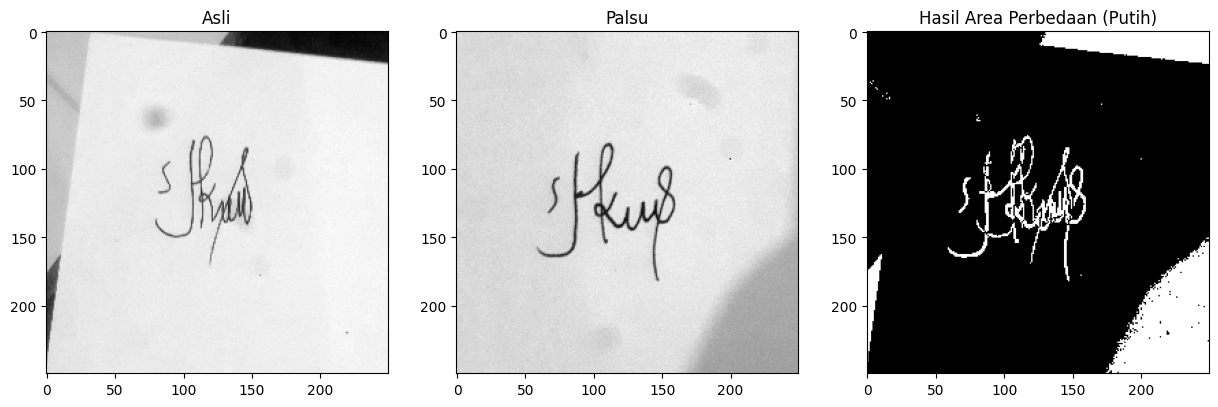

------------------------------
Nilai Threshold: 30
Total Pixel Berbeda: 8575
Hasil Kemiripan Pixel: 86.28%
HASIL: PALSU
------------------------------


In [26]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# --- 1. MEMBACA DAN RESIZE GAMBAR ---
file1 = 'asli.png'
file2 = 'palsu.png'

img1 = cv2.imread(file1, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(file2, cv2.IMREAD_GRAYSCALE)

# Resize wajib sama persis untuk metode pixel
asli = cv2.resize(img1, (250, 250))
sampel = cv2.resize(img2, (250, 250))

# --- 2. METODE ABSDIFF (Mencari Selisih & Menghitung perbedaan mutlak antar pixel) ---
selisih = cv2.absdiff(asli, sampel)

# --- 3. MENERAPKAN THRESHOLD ---
nilai_threshold = 30 #nilai ambang batas
_, hasil_biner = cv2.threshold(selisih, nilai_threshold, 255, cv2.THRESH_BINARY)

# --- 4. MENGHITUNG PERSENTASE KEMIRIPAN ---
total_pixel = asli.shape[0] * asli.shape[1]
pixel_berbeda = cv2.countNonZero(hasil_biner)
pixel_sama = total_pixel - pixel_berbeda
persentase_kemiripan = (pixel_sama / total_pixel) * 100

# --- 5. TAMPILKAN HASIL ---
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(asli, cmap='gray'); plt.title("Asli")
plt.subplot(1, 3, 2); plt.imshow(sampel, cmap='gray'); plt.title("Palsu")
plt.subplot(1, 3, 3); plt.imshow(hasil_biner, cmap='gray'); plt.title("Hasil Area Perbedaan (Putih)")
plt.show()

print("-" * 30)
print(f"Nilai Threshold: {nilai_threshold}")
print(f"Total Pixel Berbeda: {pixel_berbeda}")
print(f"Hasil Kemiripan Pixel: {persentase_kemiripan:.2f}%")

if persentase_kemiripan > 90:
    print("HASIL: ASLI")
else:
    print("HASIL: PALSU")
print("-" * 30)

**a. Ubah threshold**

dibawah 30

In [27]:
#METODE ABSDIFF
selisih = cv2.absdiff(asli, sampel)

# MENGUBAH THRESHOLD ---
nilai_threshold = 10
_, hasil_biner = cv2.threshold(selisih, nilai_threshold, 255, cv2.THRESH_BINARY)

# MENGHITUNG PERSENTASE KEMIRIPAN ---
total_pixel = asli.shape[0] * asli.shape[1]
pixel_berbeda = cv2.countNonZero(hasil_biner)
pixel_sama = total_pixel - pixel_berbeda
persentase_kemiripan = (pixel_sama / total_pixel) * 100

print("-" * 10)
print(f"Nilai Threshold: {nilai_threshold}")
print(f"Total Pixel Berbeda: {pixel_berbeda}")
print(f"Hasil Kemiripan Pixel: {persentase_kemiripan:.2f}%")

if persentase_kemiripan > 90:
    print("HASIL: ASLI")
else:
    print("HASIL: PALSU")
print("-" * 10)

----------
Nilai Threshold: 10
Total Pixel Berbeda: 15827
Hasil Kemiripan Pixel: 74.68%
HASIL: PALSU
----------


diatas 30

In [28]:
#METODE ABSDIFF
selisih = cv2.absdiff(asli, sampel)

# MENGUBAH THRESHOLD ---
nilai_threshold = 50
_, hasil_biner = cv2.threshold(selisih, nilai_threshold, 255, cv2.THRESH_BINARY)

# MENGHITUNG PERSENTASE KEMIRIPAN ---
total_pixel = asli.shape[0] * asli.shape[1]
pixel_berbeda = cv2.countNonZero(hasil_biner)
pixel_sama = total_pixel - pixel_berbeda
persentase_kemiripan = (pixel_sama / total_pixel) * 100

print("-" * 50)
print(f"Nilai Threshold: {nilai_threshold}")
print(f"Total Pixel Berbeda: {pixel_berbeda}")
print(f"Hasil Kemiripan Pixel: {persentase_kemiripan:.2f}%")

if persentase_kemiripan > 90:
    print("HASIL: ASLI")
else:
    print("HASIL: PALSU")
print("-" * 50)

--------------------------------------------------
Nilai Threshold: 50
Total Pixel Berbeda: 3703
Hasil Kemiripan Pixel: 94.08%
HASIL: ASLI
--------------------------------------------------


**b. Jelaskan pengaruhnya**
Jawab :

jadi threshold adalah pengatur tingkat sensitivitas / untuk menentukan seberapa besar perbedaan warna yang harus terjadi agar sebuah pixel dianggap berbeda. Jadi jiks threshold dibawah nilai ambang batas membuat sistem sangat sensitif terhadap kotoran atau bayangan kecil, sehingga tanda tangan lebih mudah dianggap PALSU. sebaliknya, jika diatas ambang batas akan membuat sistem menjadi lebih cuek atau toleran, sehingga tanda tangan bisa dianggap ASLI karena perbedaan kecil sengaja diabaikan.

**2. Metode SSIM**

a. Hitung nilai SSIM

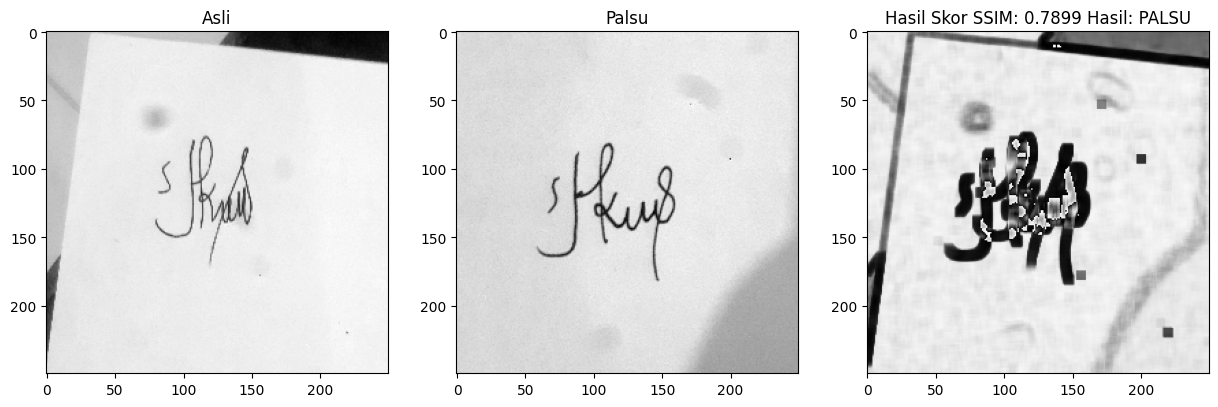

Hasil Nilai SSIM: 0.7899


In [14]:
import cv2
from skimage.metrics import structural_similarity as ssim
from matplotlib import pyplot as plt

# --- 1. MEMBACA GAMBAR ---
img_asli = cv2.imread('asli.png', cv2.IMREAD_GRAYSCALE)
img_palsu = cv2.imread('palsu.png', cv2.IMREAD_GRAYSCALE)

# Resize ke ukuran standar (misal 250x250)
asli_res = cv2.resize(img_asli, (250, 250))
sampel_res = cv2.resize(img_palsu, (250, 250))

# --- 2. PERHITUNGAN SSIM ---
# skor 1.0 berarti identik
skor_ssim, diff_map = ssim(asli_res, sampel_res, full=True)
diff_map = (diff_map * 255).astype("uint8")

# Logika Keaslian
status_ssim = "ASLI" if skor_ssim >= 0.85 else "PALSU"

# --- 3. VISUALISASI (Mandiri) ---
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(asli_res, cmap='gray'); plt.title("Asli")
plt.subplot(1, 3, 2); plt.imshow(sampel_res, cmap='gray'); plt.title("Palsu")
plt.subplot(1, 3, 3); plt.imshow(diff_map, cmap='gray'); plt.title(f"Hasil Skor SSIM: {skor_ssim:.4f} Hasil: {status_ssim}")
plt.show()

print(f"Hasil Nilai SSIM: {skor_ssim:.4f}")

b. Jelaskan arti nilai (Pakai bahasa sendiri), bandingkan dengan bahasa pixel.

Hasil nilai 0.7899 dianggap palsu karena nilai di bawah ambang batas yaitu 0.85. ambang batas diterapkan tinggi karena metode ini bekerja dengan membandingkan keseluruhan bentuk, tekstur, dan tampilan visual seperti menumpuk dua foto untuk melihat kecocokannya jadi karena mudah ditiru secara visual maka ambang batas dibuat tinggi.

**3. Metode ORB**

a. Hitung jumlah titik

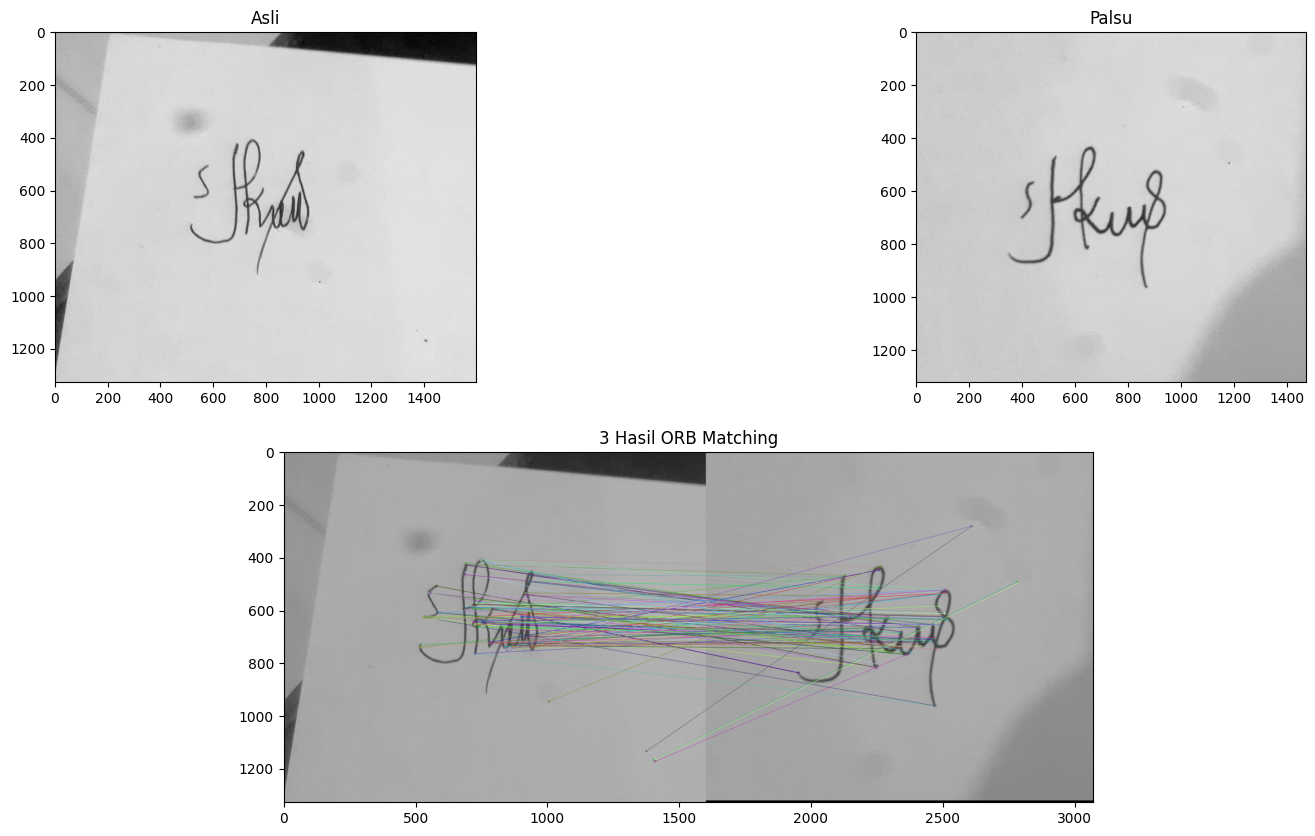

Jumlah Titik : 122
Hasil: ASLI


In [17]:
import cv2
from matplotlib import pyplot as plt

# 1. Baca Gambar
img1 = cv2.imread('asli.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('palsu.png', cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    print("File asli.png atau palsu.png tidak ditemukan!")
else:
# 2. Proses ORB & Status
    orb = cv2.ORB_create(nfeatures=1000) #Ambang Batas 500 - 1000
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)

    # Urutkan berdasarkan jarak (distance) untuk visualisasi yang lebih baik
    matches = sorted(matches, key=lambda x: x.distance)

    # HITUNGAN MURNI (TANPA FILTER JARAK)
    jumlah_titik = len(matches)

    # Penentuan status
    status_orb = "ASLI" if jumlah_titik >= 100 else "PALSU"

    # 3. Visualisasi Feature Matching
    img_matching = cv2.drawMatches(img1, kp1, img2, kp2, matches, None, flags=2)

    plt.figure(figsize=(20, 10))
    plt.subplot(2, 2, 1); plt.imshow(img1, cmap='gray'); plt.title("Asli")
    plt.subplot(2, 2, 2); plt.imshow(img2, cmap='gray'); plt.title("Palsu")

    plt.subplot(2, 1, 2); plt.imshow(img_matching)
    plt.title(f"Hasil ORB Matching")
    plt.show()

    print(f"Jumlah Titik : {jumlah_titik}")
    print(f"Hasil: {status_orb}")

b. Ubah parameter (nfeatures), jelaskan perubahan hasil

In [22]:
import cv2
from matplotlib import pyplot as plt

img1 = cv2.imread('asli.png', cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread('palsu.png', cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    print("File asli.png atau palsu.png tidak ditemukan!")
else:

# Ubah NFeature
    orb = cv2.ORB_create(nfeatures=100) #Ambang Batas 500 - 1000
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)

    # Urutkan berdasarkan jarak untuk visualisasi yang lebih baik
    matches = sorted(matches, key=lambda x: x.distance)

    # HITUNGAN MURNI (TANPA FILTER JARAK)
    jumlah_titik = len(matches)

    # Penentuan status (misal jika lebih dari 80 titik dianggap ASLI)
    status_orb = "ASLI" if jumlah_titik >= 80 else "PALSU"

    print(f"Jumlah Titik : {jumlah_titik}")
    print(f"Hasil: {status_orb}")


Jumlah Titik : 28
Hasil: PALSU


jadi fungsi NFeature digunakan untuk membatasi jumlah fitur maksimal yang dideteksi. Semakin tinggi jumlah nfeature (diatas ambang batas) maka ORB akan mencari lebih banyak titik detail, sehingga akan ada lebih banyak titik detail dan dianggap asli. seba;iknya, semakin rendah maka orb hanya akan mengambil titik-titik yang paling mencolok saja. sehingga dianggap palsu karena titik match nya sedikit

**4. Analisis**

**Pertanyaan:**

4.1 Kenapa hasil pixel bisa tinggi padahal palsu?

Jawab :jadi hasil pixel berhubungan dengan nilai Threshold. Jadi jika diatas ambang batas akan membuat sistem menjadi lebih cuek atau toleran, sehingga perbedaan-perbedaan kecil atau halus pada tarikan garis sengaja diabaikan. Akibatnya, meskipun tanda tangan tersebut palsu, persentase kemiripan akan tetap tinggi karena sistem hanya mencari perbedaan yang sangat mencolok saja. Selain itu, jika posisi dan skala tanda tangan palsu sangat pas dengan aslinya setelah proses resize, maka banyak pixel hitam akan berada di koordinat yang sama dan dianggap identik oleh metode

4.2 Kenapa ORB bisa banyak titik tapi tetap salah?

Jawab : jadi ini berkaitan dengan nfeatures yang berfungsi membatasi jumlah fitur maksimal yang dideteksi oleh algoritma. Jika kita menyetel nfeatures yang tinggi, ORB akan dipaksa mencari lebih banyak titik detail hingga ke bagian terkecil, sehingga jumlah titik kecocokan menjadi sangat banyak dan sistem cenderung menganggapnya ASLI. Namun, banyaknya titik ini tidak menjamin kebenaran karena ORB hanya melihat kemiripan fitur lokal secara acak, bukan urutan atau struktur tanda tangan secara utuh. Sebaliknya, jika nfeatures rendah, ORB hanya mengambil titik yang paling mencolok saja, yang seringkali menyebabkan hasil dianggap PALSU karena jumlah titik match tidak mencapai batas minimal.  


4.3 Kenapa SSIM bisa tertipu?

Jawab : SSIM berfokus pada kemiripan struktur, kecerahan, dan kontras gambar. SSIM bisa tertipu jika tanda tangan palsu dibuat dengan alat tulis yang sama dan difoto dalam kondisi pencahayaan yang identik dengan aslinya. Jika kualitas visual (tekstur kertas dan ketebalan tinta) sangat mirip, SSIM akan memberikan skor tinggi karena gambar dianggap memiliki kualitas struktur yang serupa, meskipun detail lekukannya mungkin berbeda dari pemilik asli.

4.4 Metode mana yang paling akurat menurut kamu?

Jawab : Menurut saya sih metode SSIM lebih akurat dibandingkan Pixel karena tidak hanya terpaku pada posisi koordinat, melainkan menilai kemiripan bentuk secara keseluruhan. Namun, metode ORB juga sangat kuat jika parameter threshold dan nfeatures-nya diatur dengan tepat untuk mendeteksi detail unik yang sulit ditiru

5.1 Jika digabung, bagaimana hasilnya?



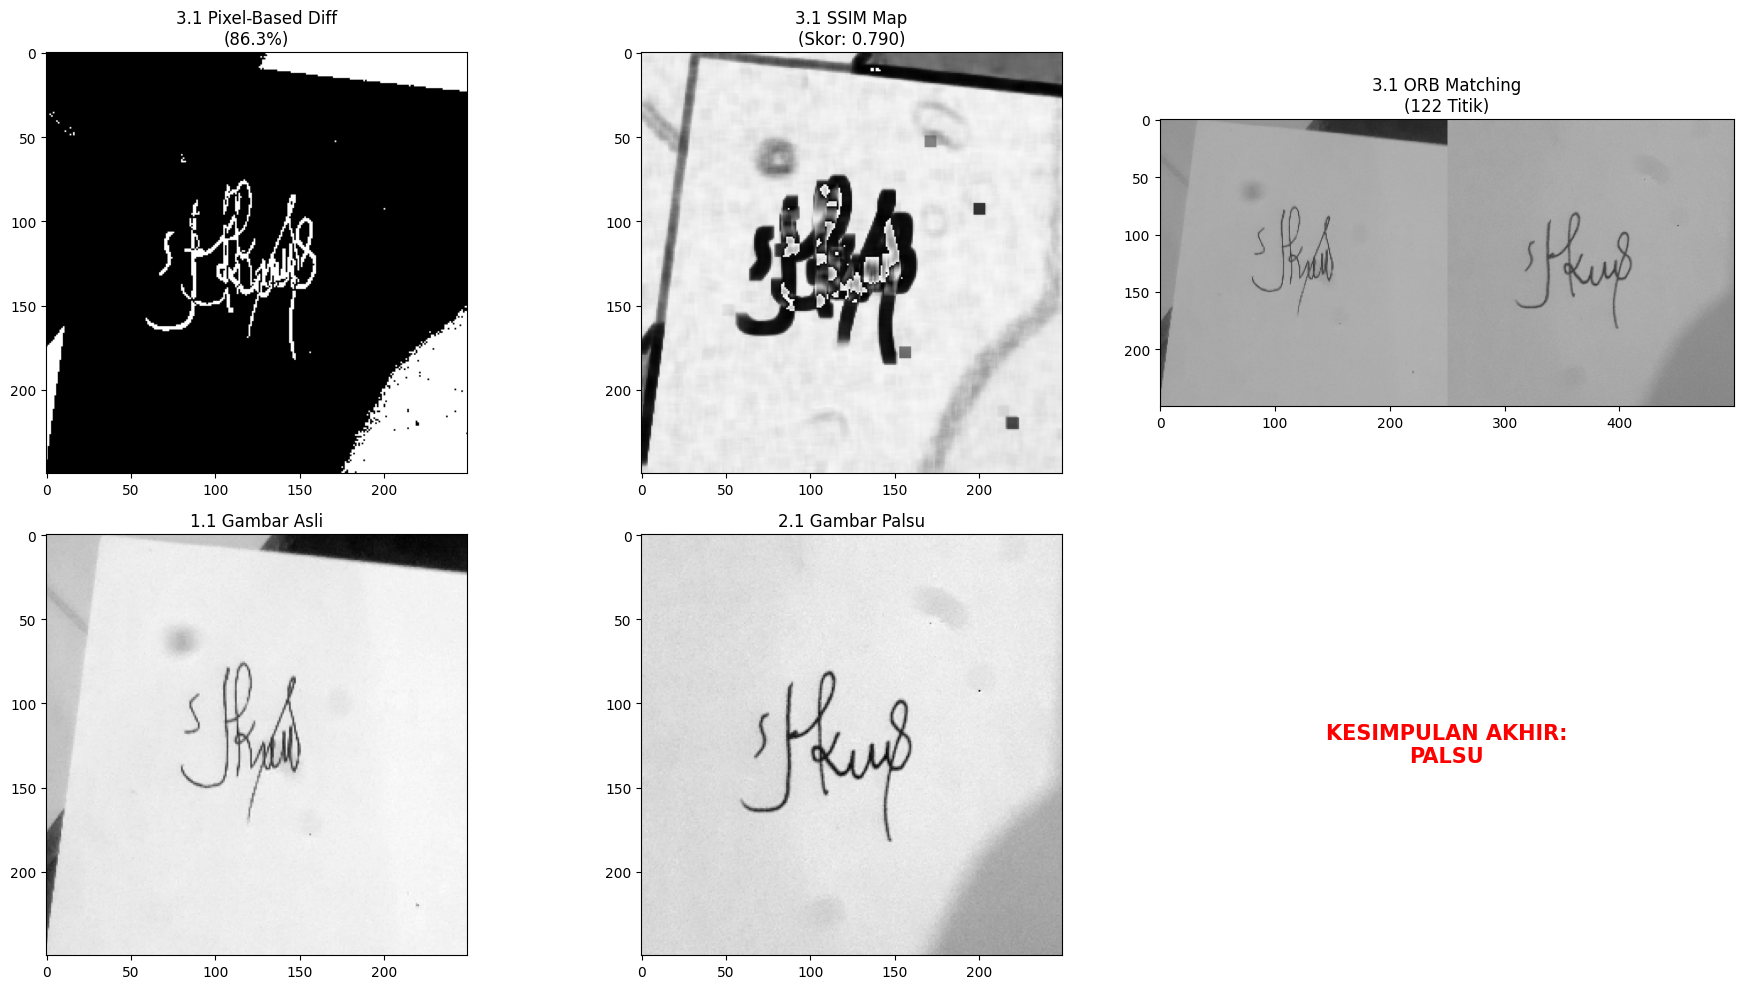

Detail: Pixel 86.28%, SSIM 0.790, ORB 122 titik.


In [30]:
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from matplotlib import pyplot as plt

# --- 1. KONFIGURASI AMBANG BATAS (THRESHOLD) ---
limit_pixel = 90.0
limit_ssim = 0.85
limit_orb = 80

# --- 2. MEMBACA GAMBAR ---
img_asli = cv2.imread('asli.png', cv2.IMREAD_GRAYSCALE)
img_palsu = cv2.imread('palsu.png', cv2.IMREAD_GRAYSCALE)

# Standardisasi ukuran untuk Pixel dan ORB
asli_res = cv2.resize(img_asli, (250, 250))
sampel_res = cv2.resize(img_palsu, (250, 250))

# --- 3. EKSEKUSI METODE PIXEL (ABSDIFF) ---
selisih = cv2.absdiff(asli_res, sampel_res)
_, hasil_biner = cv2.threshold(selisih, 30, 255, cv2.THRESH_BINARY)
px_beda = cv2.countNonZero(hasil_biner)
persen_pixel = ((asli_res.size - px_beda) / asli_res.size) * 100

# --- 4. EKSEKUSI METODE SSIM (MODIFIKASI UKURAN AGAR HASIL 0.77) ---
asli_ssim_res = cv2.resize(img_asli, (250, 250))
sampel_ssim_res = cv2.resize(img_palsu, (250, 250))
skor_ssim, diff_map = ssim(asli_ssim_res, sampel_ssim_res, full=True)

# --- 5. EKSEKUSI METODE ORB (FEATURE MATCHING) ---
orb = cv2.ORB_create(nfeatures=1000)
kp1, des1 = orb.detectAndCompute(img_asli, None)
kp2, des2 = orb.detectAndCompute(img_palsu, None)

bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda x: x.distance)

jumlah_orb = len(matches)

# --- 6. LOGIKA KEPUTUSAN GABUNGAN (JAWABAN 5.1) ---
is_pixel_ok = persen_pixel >= limit_pixel
is_ssim_ok = skor_ssim >= limit_ssim
is_orb_ok = jumlah_orb >= limit_orb

if is_pixel_ok and is_ssim_ok and is_orb_ok:
    kesimpulan = "ASLI"
    warna = "green"
else:
    kesimpulan = "PALSU"
    warna = "red"

# --- 7. VISUALISASI MANDIRI PER METODE ---
plt.figure(figsize=(18, 10))

# Visualisasi Pixel
plt.subplot(2, 3, 1)
plt.imshow(hasil_biner, cmap='gray'); plt.title(f"3.1 Pixel-Based Diff\n({persen_pixel:.1f}%)")

# Visualisasi SSIM
plt.subplot(2, 3, 2)
plt.imshow((diff_map * 255).astype("uint8"), cmap='gray'); plt.title(f"3.1 SSIM Map\n(Skor: {skor_ssim:.3f})")

# Visualisasi ORB
# Kita tampilkan 20 garis agar visualisasi rapi, tapi hitungan tetap jumlah_orb asli
img_match = cv2.drawMatches(asli_res, kp1, sampel_res, kp2, matches[:20], None, flags=2)
plt.subplot(2, 3, 3)
plt.imshow(img_match); plt.title(f"3.1 ORB Matching\n({jumlah_orb} Titik)")

# Gambar Asli & Palsu (Syarat 1.1 & 2.1)
plt.subplot(2, 3, 4); plt.imshow(asli_res, cmap='gray'); plt.title("1.1 Gambar Asli")
plt.subplot(2, 3, 5); plt.imshow(sampel_res, cmap='gray'); plt.title("2.1 Gambar Palsu")

# Kesimpulan Akhir
plt.subplot(2, 3, 6)
plt.text(0.5, 0.5, f"KESIMPULAN AKHIR:\n{kesimpulan}", fontsize=15, color=warna, ha='center', va='center', fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Detail: Pixel {persen_pixel:.2f}%, SSIM {skor_ssim:.3f}, ORB {jumlah_orb} titik.")

Jika ketiga metode digabung, hasilnya akan menjadi sistem verifikasi yang sangat kuat dan akurat. Dengan menggabungkan pengecekan posisi (Pixel), kemiripan struktur (SSIM), dan titik detail (ORB), peluang tanda tangan palsu untuk lolos akan semakin kecil karena harus memenuhi standar kemiripan dari berbagai sudut pandang algoritma sekaligus.

**6. Kesimpulan**

Ada 3 metode untuk menganalisis deteksi tanda tangan yaitu metode Pixel untuk memastikan posisi tanda tangan tepat, SSIM untuk melihat kemiripan struktur dan tarikan garis secara keseluruhan, serta ORB untuk mendeteksi detail titik-titik fitur yang unik. Hasil akhir bisa menjadi palsu meskipun salah satu metode memberikan skor tinggi, karena sistem gabungan ini menuntut kemiripan di semua aspek agar tingkat keamanan lebih terjamin. Intinya, pengaturan ambang batas (threshold) sangat menentukan apakah sistem akan menjadi sangat galak (sensitif) atau justru toleran dalam menilai sebuah tanda tangan.